Epochs:   5%|▌         | 1/20 [00:03<01:12,  3.83s/it]

Epoch 1/20  Train loss 2.6659, acc 0.1611  |  Val loss 2.1483, acc 0.3257


Epochs:  10%|█         | 2/20 [00:06<00:53,  2.98s/it]

Epoch 2/20  Train loss 1.8917, acc 0.3921  |  Val loss 1.6412, acc 0.4575


Epochs:  15%|█▌        | 3/20 [00:08<00:44,  2.64s/it]

...

Epoch 18/20  Train loss 0.8965, acc 0.6926  |  Val loss 0.8526, acc 0.7167


Epochs:  95%|█████████▌| 19/20 [00:40<00:02,  2.39s/it]

Epoch 19/20  Train loss 0.8714, acc 0.7039  |  Val loss 0.9268, acc 0.6696


Epochs: 100%|██████████| 20/20 [00:40<00:00,  2.01s/it]


Epoch 20/20  Train loss 0.8550, acc 0.7083  |  Val loss 0.8588, acc 0.7008


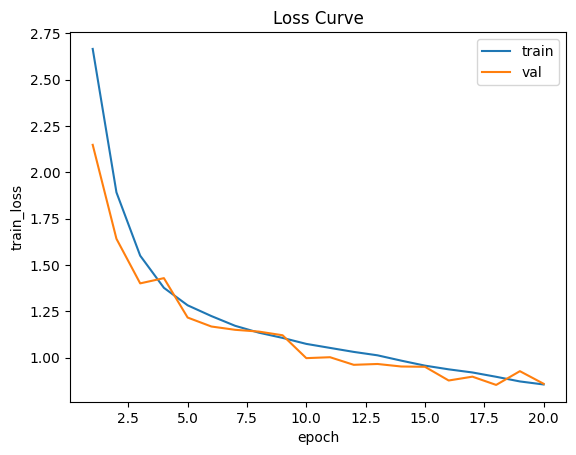

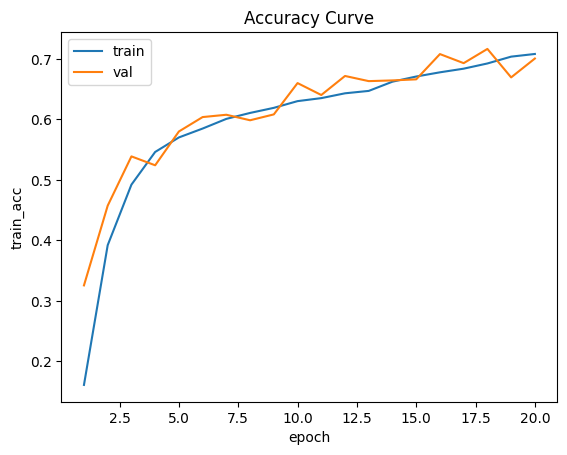

Testing: 100%|██████████| 107/107 [00:00<00:00, 1599.81it/s]


Test Accuracy : 0.7013827596351868
Precision      : 0.7428590967880216
Recall         : 0.7013827596351868
F1 Score       : 0.7094314513556649


Predicting probabilities: 100%|██████████| 107/107 [00:00<00:00, 1577.29it/s]


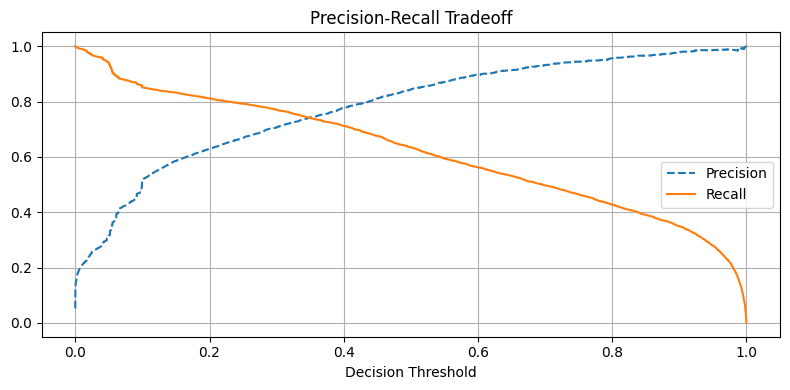

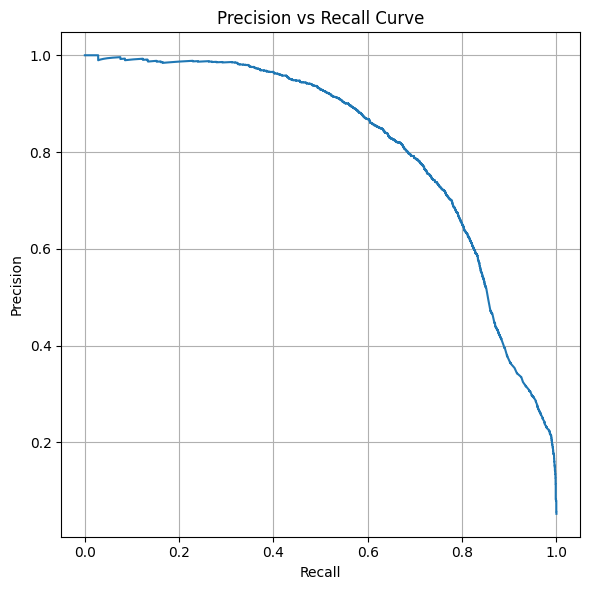

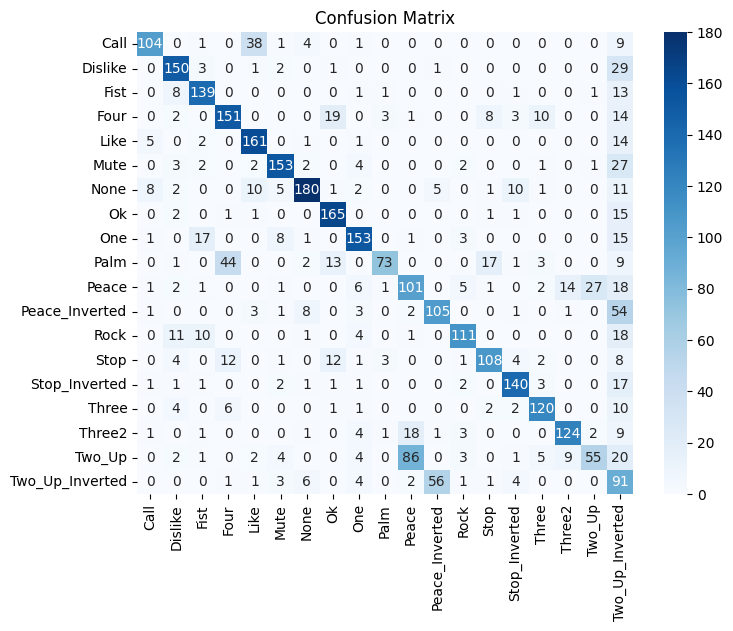

In [ ]:
import os
import glob
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix
)
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm, trange
import mediapipe as mp
import cv2

# ---- Config ----
"""
Configuration parameters for two-hand gesture model analysis:
- dataset_path: path to gesture image dataset
- CACHE_FILE: path to cached landmarks
- BATCH_SIZE, LR, EPOCHS: training hyperparameters
- VAL_SPLIT, TEST_SPLIT: dataset splits for validation and test
- DEVICE: CPU or GPU
- total_landmarks: expected max feature dimension (used for caching)
"""

dataset_path    = 'hagrid-sample-30k-384p/hagrid_30k'
CACHE_FILE      = 'hand_landmarks_two_hands.npz'
BATCH_SIZE      = 32
LR              = 1e-3
EPOCHS          = 20
VAL_SPLIT       = 0.1
TEST_SPLIT      = 0.1
DEVICE          = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

total_landmarks = 21 * 3 * 2  # maximum features for two hands

# ---- Preprocessing: extract and cache landmarks ----
def preprocess_and_cache(root_dir: str, out_file: str) -> None:
    """
    Extract and cache hand landmarks for up to two hands from a dataset.

    Args:
        root_dir (str): Root directory containing subfolders per gesture class with images.
        out_file (str): Output .npz file to store features, labels, and class names.

    This function processes each JPEG image using MediaPipe Hands, extracts up to
    two hands' landmarks (pads if only one hand detected), and saves the data.
    """
    files = glob.glob(os.path.join(root_dir, '*/*.jpg'))
    class_names = sorted(os.listdir(root_dir))
    labels_map = {name: idx for idx, name in enumerate(class_names)}

    all_feats, all_labels = [], []
    hands = mp.solutions.hands.Hands(static_image_mode=True,
                                     max_num_hands=2,
                                     min_detection_confidence=0.5)
    for img_path in tqdm(files, desc='Extracting landmarks'):
        img = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        res = hands.process(img_rgb)

        # initialize zeros for both hands
        coords = [0.0] * total_landmarks
        if res.multi_hand_landmarks:
            feats = []
            # collect landmarks for up to two hands
            for lm in res.multi_hand_landmarks[:2]:
                feats.extend([coord for pt in lm.landmark for coord in (pt.x, pt.y, pt.z)])
            # pad if only one hand
            if len(res.multi_hand_landmarks) == 1:
                feats.extend([0.0] * (21 * 3))
            coords = feats
        all_feats.append(np.array(coords, dtype=np.float32))

        label = labels_map[os.path.basename(os.path.dirname(img_path))]
        all_labels.append(label)
    hands.close()

    np.savez(out_file,
             features=np.stack(all_feats),
             labels=np.array(all_labels),
             classes=class_names)
    print(f"Saved cached landmarks and labels to {out_file}")

# ---- Dataset ----
class CachedHandDataset(Dataset):
    """
    PyTorch Dataset for loading cached two-hand landmarks from a .npz file.

    Attributes:
        features (np.ndarray): Array of shape (N, D) of hand landmarks.
        labels (np.ndarray): Array of shape (N,) of integer class labels.
        classes (list): List of class names.
    """
    def __init__(self, cache_path: str):
        data = np.load(cache_path, allow_pickle=True)
        self.features = data['features']
        self.labels   = data['labels']
        self.classes  = data['classes']

    def __len__(self) -> int:
        """Return the total number of samples."""
        return len(self.labels)

    def __getitem__(self, idx: int):
        """
        Retrieve feature and label for a given index.

        Args:
            idx (int): Index of the sample to retrieve.

        Returns:
            tuple: (feature_tensor, label_int)
        """
        feat = torch.from_numpy(self.features[idx]).float()
        lbl  = int(self.labels[idx])
        return feat, lbl

# ---- Model ----
class HandNet(nn.Module):
    """
    Fully-connected network for gesture classification.

    Args:
        input_size (int): Number of input features determined by dataset.
        hidden_size (int): Number of hidden units per layer.
        num_classes (int): Number of gesture classes.
    """
    def __init__(self, input_size: int, hidden_size: int = 128, num_classes: int = 19):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, num_classes)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Perform a forward pass and return raw logits."""
        return self.net(x)

# ---- Training/Eval Logic ----
def train_epoch(model, loader, criterion, optimizer):
    """
    Train the model for one epoch.

    Returns:
        tuple: (average_loss, accuracy)
    """
    model.train()
    total_loss, correct, total = 0, 0, 0
    for Xb, yb in tqdm(loader, desc="Training", leave=False):
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(Xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * Xb.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)
    return total_loss/total, correct/total


def eval_epoch(model, loader, criterion, phase="Validation"):
    """
    Evaluate the model on a given dataset split.

    Returns:
        tuple: (average_loss, accuracy)
    """
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for Xb, yb in tqdm(loader, desc=phase, leave=False):
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            logits = model(Xb)
            loss = criterion(logits, yb)
            total_loss += loss.item() * Xb.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)
    return total_loss/total, correct/total

# ---- Main ----
def main() -> None:
    """
    Full pipeline: preprocess cache, train model, evaluate, and visualize results.
    """
    # regenerate cache if missing
    if not os.path.exists(CACHE_FILE):
        preprocess_and_cache(dataset_path, CACHE_FILE)

    # Load dataset and infer feature dimension
    ds = CachedHandDataset(CACHE_FILE)
    feature_dim = ds.features.shape[1]

    # Split dataset
    n = len(ds)
    nv = int(n * VAL_SPLIT)
    nt = int(n * TEST_SPLIT)
    ntotal = n - nv - nt
    train_ds, val_ds, test_ds = random_split(ds, [ntotal, nv, nt])
    train_ld = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_ld   = DataLoader(val_ds,   batch_size=BATCH_SIZE)
    test_ld  = DataLoader(test_ds,  batch_size=BATCH_SIZE)

    # Model setup using inferred input size
    model = HandNet(input_size=feature_dim, hidden_size=128, num_classes=len(ds.classes)).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LR)

    # Training loop with logging
    hist = {"epoch":[], "train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[]}
    for ep in tqdm(range(1, EPOCHS+1), desc="Epochs"):
        tl, ta = train_epoch(model, train_ld, criterion, optimizer)
        vl, va = eval_epoch(model, val_ld, criterion)
        hist["epoch"].append(ep)
        hist["train_loss"].append(tl)
        hist["val_loss"].append(vl)
        hist["train_acc"].append(ta)
        hist["val_acc"].append(va)
        print(f"Epoch {ep}/{EPOCHS}  Train loss {tl:.4f}, acc {ta:.4f}  |  Val loss {vl:.4f}, acc {va:.4f}")

    # Plot learning curves
    df = pd.DataFrame(hist)
    plt.figure(); sns.lineplot(data=df, x="epoch", y="train_loss", label="train")
    sns.lineplot(data=df, x="epoch", y="val_loss", label="val")
    plt.title("Loss Curve"); plt.show()

    plt.figure(); sns.lineplot(data=df, x="epoch", y="train_acc", label="train")
    sns.lineplot(data=df, x="epoch", y="val_acc", label="val")
    plt.title("Accuracy Curve"); plt.show()

    # Test metrics
    ys, ps = [], []
    model.eval()
    with torch.no_grad():
        for Xb, yb in tqdm(test_ld, desc="Testing"):
            Xb = Xb.to(DEVICE)
            logits = model(Xb)
            preds = logits.argmax(dim=1).cpu().numpy()
            ys.extend(yb.numpy()); ps.extend(preds)
    print("Test Accuracy :", accuracy_score(ys, ps))
    print("Precision      :", precision_score(ys, ps, average="weighted"))
    print("Recall         :", recall_score(ys, ps, average="weighted"))
    print("F1 Score       :", f1_score(ys, ps, average="weighted"))

    # Precision-Recall Curve
    y_true = np.array(ys)
    n_classes = len(ds.classes)
    y_bin = label_binarize(y_true, classes=range(n_classes))
    all_probs = []
    with torch.no_grad():
        for Xb, _ in tqdm(test_ld, desc="Predicting probabilities"):
            Xb = Xb.to(DEVICE)
            probs = torch.softmax(model(Xb), dim=1).cpu().numpy()
            all_probs.append(probs)
    all_probs = np.vstack(all_probs)

    precision, recall, thresholds = precision_recall_curve(y_bin.ravel(), all_probs.ravel())

    plt.figure(figsize=(8, 4))
    plt.plot(thresholds, precision[:-1], '--', label='Precision')
    plt.plot(thresholds, recall[:-1],    '-',  label='Recall')
    plt.xlabel('Decision Threshold')
    plt.title('Precision-Recall Tradeoff')
    plt.legend(loc='best')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 6))
    plt.plot(recall, precision, '-')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision vs Recall Curve')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Confusion matrix
    cm = confusion_matrix(ys, ps)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=ds.classes, yticklabels=ds.classes, cmap="Blues")
    plt.title("Confusion Matrix"); plt.show()

    # Save model
    torch.save(model.state_dict(), "handnet_two_hands.pth")

if __name__ == "__main__":
    main()


Dataset loaded: 33997 samples, 63 features
Number of classes: 19


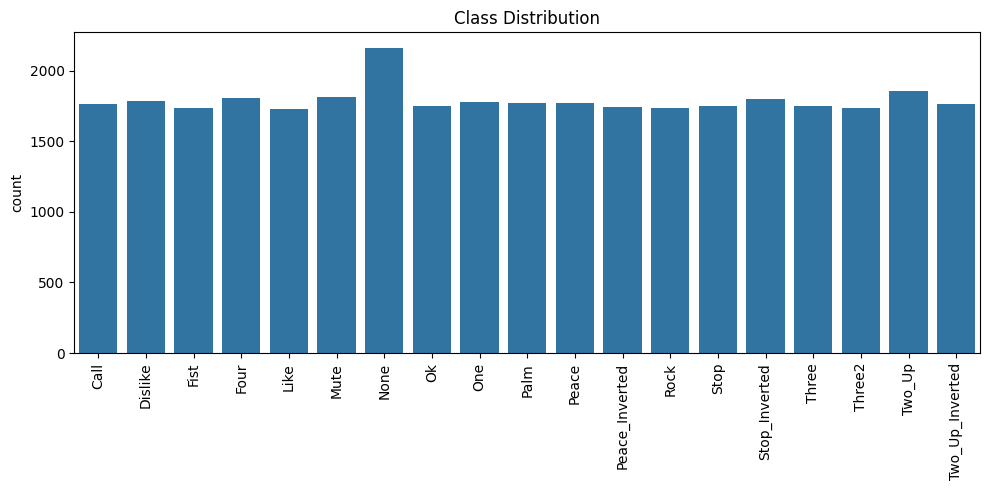


--- Landmark Value Statistics ---
Feature mean (global): 0.2864
Feature std (global): 0.1497

--- NaN / Missing Value Check ---
Total NaNs in dataset: 0


In [ ]:
# ---- Dataset Statistics ----

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.decomposition import PCA

# Load data
data = np.load("hand_landmarks.npz", allow_pickle=True)
X = data["features"]  # shape: (N, 63)
y = data["labels"]
class_names = data["classes"]

print(f"Dataset loaded: {X.shape[0]} samples, {X.shape[1]} features")
print(f"Number of classes: {len(class_names)}")



